In [4]:
!pip install tqdm regex

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 675.5/675.5 kB 1.2 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.8/801.8 kB 5.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [regex]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 4.37.2 requires safetensors>=0.4.1, which is not installed.
sacrebleu 2.6.0 requires colorama, which is not installed.
sacrebleu 2.6.0 requires lxml, which is not installed.
sacrebleu 2.6.0 requires tabulate>=0.8.9, which is not installed.
peft 0.4.0 requires safetensors, which is not installed.
huggingface-hub 0.36.2 requires hf-xet<2.0.0,>=1.1.3; platform_machine == "x86_64" or platform_machine == "amd64" or platform_machine == "arm64" or platform_machine == "aarch64", which is not installed.


In [6]:
!pip install -q --no-deps \
"bitsandbytes==0.48.1" \
"transformers==4.37.2" \
"tokenizers==0.15.1" \
"accelerate==0.21.0" \
"peft==0.4.0" \
"einops==0.6.1" \
"einops-exts==0.0.4" \
"sentencepiece==0.1.99" \
"timm==0.6.13" \
"huggingface-hub==0.36.2" \
shortuuid sacrebleu portalocker

In [8]:
pip install --force-reinstall --no-deps safetensors

Note: you may need to restart the kernel to use updated packages.


In [9]:
# cek env
import torch, bitsandbytes as bnb
import transformers, accelerate, peft, tokenizers

print("torch:", torch.__version__, torch.cuda.is_available(), torch.version.cuda)
print("bnb:", bnb.__version__)
print("transformers:", transformers.__version__)
print("accelerate:", accelerate.__version__)
print("peft:", peft.__version__)
print("tokenizers:", tokenizers.__version__)

from transformers.trainer import ALL_LAYERNORM_LAYERS
print("✅ env aman")

torch: 2.8.0+cu128 True 12.8
bnb: 0.48.1
transformers: 4.37.2
accelerate: 0.21.0
peft: 0.4.0
tokenizers: 0.15.1
✅ env aman


In [11]:
!pip install deepspeed

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 7.3 MB/s  0:00:00m eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 6.1 MB/s  0:00:000m eta 0:00:01
  Created wheel for deepspeed: filename=deepspeed-0.19.3-py3-none-any.whl size=1981990 sha256=b9e2bc7c59a83125ae9cd34e59216f26c210101521c83f2d2d05ed85b06d79f3
  Stored in directory: /workspace/.cache/pip/wheels/ad/b5/17/8a0622bdb51b91b9fe37b9d6026f26e58a288bec0835a0c658
Successfully built deepspeed
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [deepspeed]/9 [deepspeed]


In [12]:
import deepspeed, sys

print(sys.version)
print(deepspeed.__version__)

/usr/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/usr/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status


3.12.3 (main, Aug 14 2025, 17:47:21) [GCC 13.3.0]
0.19.3


In [1]:
# Clone repo
!git clone https://github.com/X-PLUG/mPLUG-DocOwl.git

Cloning into 'mPLUG-DocOwl'...
remote: Enumerating objects: 879, done.
remote: Counting objects: 100% (87/87), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 879 (delta 56), reused 62 (delta 47), pack-reused 792 (from 1)
Receiving objects: 100% (879/879), 107.21 MiB | 24.11 MiB/s, done.
Resolving deltas: 100% (382/382), done.
Updating files: 100% (396/396), done.


In [13]:
# Cell 1b: Pindah direktori
%cd /workspace/mPLUG-DocOwl/TinyChart

/workspace/mPLUG-DocOwl/TinyChart


In [14]:
# Install tanpa strict dependencies
!pip install -e . --no-deps -q

In [15]:
import torch
print(torch.__version__)        # cek versi torch
print(torch.cuda.is_available()) # pastikan GPU terdeteksi

2.8.0+cu128
True


In [17]:
# Download base model
!git lfs install
!git clone https://huggingface.co/bczhou/TinyLLaVA-3.1B-SigLIP /workspace/mPLUG-DocOwl/TinyChart/pretrained_models/TinyLLaVA-3.1B-SigLIP

git: 'lfs' is not a git command. See 'git --help'.

The most similar command is
	log
Cloning into '/workspace/mPLUG-DocOwl/TinyChart/pretrained_models/TinyLLaVA-3.1B-SigLIP'...
remote: Enumerating objects: 11, done.
remote: Total 11 (delta 0), reused 0 (delta 0), pack-reused 11 (from 1)
Receiving objects: 100% (11/11), done.
Resolving deltas: 100% (1/1), done.


In [ ]:
# login HF
from huggingface_hub import login

login(token=os.getenv("HF_TOKEN"))

In [19]:
from huggingface_hub import list_repo_files

files = list_repo_files(
    repo_id="shiinn97/indochartqa",
    repo_type="dataset"
)

for f in files:
    print(f)

.gitattributes
README.md
data/test-00000-of-00001.parquet
data/train-00000-of-00001.parquet
data/validation-00000-of-00001.parquet
tinychart_images.tar


In [23]:
!pip install hf_transfer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 13.8 MB/s  0:00:00 eta 0:00:01


In [24]:
from datasets import load_dataset

dataset = load_dataset("shiinn97/indochartqa")

dataset["train"].to_json("/workspace/train.json")
dataset["validation"].to_json("/workspace/validation.json")
dataset["test"].to_json("/workspace/test.json")

README.md:   0%|          | 0.00/636 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


train-00000-of-00001.parquet:   0%|          | 0.00/1.76M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


validation-00000-of-00001.parquet:   0%|          | 0.00/236k [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/11830 [00:00<?, ? examples/s]

Creating json from Arrow format:   0%|          | 0/82 [00:00<?, ?ba/s]

Creating json from Arrow format:   0%|          | 0/12 [00:00<?, ?ba/s]

Creating json from Arrow format:   0%|          | 0/12 [00:00<?, ?ba/s]

6914101

In [25]:
from datasets import load_dataset
import json
import os

dataset = load_dataset("shiinn97/indochartqa")

for split in ["train", "validation", "test"]:
    out_path = f"/workspace/{split}.json"

    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(
            dataset[split].to_list(),
            f,
            ensure_ascii=False,
            indent=2
        )

    print(f"✅ Saved {out_path}")

✅ Saved /workspace/train.json
✅ Saved /workspace/validation.json
✅ Saved /workspace/test.json


In [27]:
with open("/workspace/train.json", encoding="utf-8") as f:
    data = json.load(f)

print(type(data))
print(len(data))
print(data[0])

<class 'list'>
81592
{'id': 'S669BARSelection_1', 'image': 'Sulsel/WM_BAR/Indeks Harga Konsumen Bulanan Menurut 5 Kota Inflasi di Provinsi Sulawesi Selatan, Juli 2009/2D_Horizontal_Style1.png', 'conversations': [{'from': 'human', 'value': '<image>\nBerapa Indeks Harga Konsumen Bulanan di Pare-Pare pada bulan Juli 2009?'}, {'from': 'gpt', 'value': '120'}]}


In [28]:
import json

for split in ["train", "validation", "test"]:
    with open(f"/workspace/{split}.json", encoding="utf-8") as f:
        data = json.load(f)
    print(split, len(data))

train 81592
validation 11256
test 11830


In [29]:
from huggingface_hub import hf_hub_download

hf_hub_download(
    repo_id="shiinn97/indochartqa",
    filename="tinychart_images.tar",
    repo_type="dataset",
    local_dir="/workspace"
)

print("✅ tinychart_images.tar downloaded")

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


tinychart_images.tar:   0%|          | 0.00/1.01G [00:00<?, ?B/s]

✅ tinychart_images.tar downloaded


In [30]:
import tarfile

with tarfile.open("/workspace/tinychart_images.tar", "r") as tar:
    tar.extractall("/workspace")

print("✅ Images extracted")

✅ Images extracted


In [31]:
# Patch ToMe pada base model
import shutil

model_path = "/workspace/mPLUG-DocOwl/TinyChart/pretrained_models/TinyLLaVA-3.1B-SigLIP"
shutil.copy(f"{model_path}/config.json", f"{model_path}/config.json.bak")

%cd /workspace/mPLUG-DocOwl/TinyChart
!python scripts/vit_add_tome.py --path {model_path}
print("✅ ToMe patch done")

/workspace/mPLUG-DocOwl/TinyChart
✅ ToMe patch done


In [32]:
# buat zero2.json
import json, os

zero2 = {
    "fp16": {
        "enabled": True,
        "loss_scale": 0,
        "loss_scale_window": 1000,
        "initial_scale_power": 16,
        "hysteresis": 2,
        "min_loss_scale": 1
    },
    "bf16": {
        "enabled": False
    },
    "zero_optimization": {
        "stage": 2,
        "offload_optimizer": {
            "device": "cpu",
            "pin_memory": True
        },
        "allgather_partitions": True,
        "allgather_bucket_size": 2e8,
        "overlap_comm": False,
        "reduce_scatter": True,
        "reduce_bucket_size": 2e8,
        "contiguous_gradients": True
    },
    "gradient_accumulation_steps": "auto",
    "gradient_clipping": "auto",
    "train_batch_size": "auto",
    "train_micro_batch_size_per_gpu": "auto",
    "steps_per_print": 2000,
    "wall_clock_breakdown": False
}

path = "/workspace/mPLUG-DocOwl/TinyChart/scripts/zero2.json"

with open(path, "w") as f:
    json.dump(zero2, f, indent=2)

print("created:", path)

created: /workspace/mPLUG-DocOwl/TinyChart/scripts/zero2.json


In [7]:
!pip install tensorboard

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 16.1 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 7.7 MB/s  0:00:000m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 29.5 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [tensorboard] [tensorboard]


In [19]:
import shutil
shutil.rmtree("/workspace/checkpoints/TinyChart-3B", ignore_errors=True)

In [12]:
train_sh = """#!/bin/bash
TRAIN_DATA=/workspace/train.json
VAL_DATA=/workspace/validation.json
TEST_DATA=/workspace/test.json
LLM_PATH=mPLUG/TinyChart-3B-768
VIT_PATH=mPLUG/TinyChart-3B-768-siglip
OUTPUT=/workspace/checkpoints/TinyChart-3B
mkdir -p ${OUTPUT}
cp scripts/train_runpod.sh ${OUTPUT}/
export PYTHONPATH=./
export RANK=0
python \\
    tinychart/train/train.py \\
    --lora_enable True \\
    --lora_r 128 \\
    --lora_alpha 256 \\
    --lora_dropout 0.05 \\
    --tune_vision_tower False \\
    --tune_entire_model False \\
    --tune_vit_from_layer -1 \\
    --model_name_or_path ${LLM_PATH} \\
    --vision_tower ${VIT_PATH} \\
    --version v1 \\
    --data_path ${TRAIN_DATA} \\
    --eval_data_path ${VAL_DATA} \\
    --image_folder /workspace/tinychart_images \\
    --mm_projector_type mlp2x_gelu \\
    --mm_vision_select_layer -2 \\
    --mm_use_im_start_end False \\
    --mm_use_im_patch_token False \\
    --image_aspect_ratio pad \\
    --group_by_modality_length True \\
    --fp16 False \\
    --bf16 True \\
    --output_dir ${OUTPUT} \\
    --num_train_epochs 1 \\
    --per_device_train_batch_size 2 \\
    --per_device_eval_batch_size 2 \\
    --gradient_accumulation_steps 1 \\
    --evaluation_strategy "steps" \\
    --eval_steps 20000 \\
    --save_strategy "steps" \\
    --save_steps 20000 \\
    --load_best_model_at_end True \\
    --metric_for_best_model eval_loss \\
    --greater_is_better False \\
    --save_total_limit 3 \\
    --learning_rate 1e-4 \\
    --weight_decay 0. \\
    --warmup_ratio 0.03 \\
    --lr_scheduler_type "cosine" \\
    --logging_steps 50 \\
    --tf32 True \\
    --model_max_length 1024 \\
    --gradient_checkpointing True \\
    --dataloader_num_workers 6 \\
    --lazy_preprocess True \\
    --report_to tensorboard \\
2>&1 | tee -a ${OUTPUT}/log.txt
python scripts/convert_model_config.py --input ${OUTPUT}
# bash scripts/evaluate.sh ${OUTPUT} ${TEST_DATA}
"""
with open("/workspace/mPLUG-DocOwl/TinyChart/scripts/train_runpod.sh", "w") as f:
    f.write(train_sh)
print("✅ train_runpod.sh created")

✅ train_runpod.sh created


In [9]:
!pip install tabulate

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sacrebleu 2.6.0 requires colorama, which is not installed.
sacrebleu 2.6.0 requires lxml, which is not installed.


In [37]:
pip uninstall -y deepspeed

Found existing installation: deepspeed 0.19.3
Uninstalling deepspeed-0.19.3:
  Successfully uninstalled deepspeed-0.19.3
Note: you may need to restart the kernel to use updated packages.


In [ ]:
%cd /workspace/mPLUG-DocOwl/TinyChart
!bash scripts/train_runpod.sh

/workspace/mPLUG-DocOwl/TinyChart
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Loading checkpoint shards: 100%|██████████| 3/3 [00:41<00:00, 13.70s/it]
Some weights of the model checkpoint at mPLUG/TinyChart-3B-768 were not used when initializing TinyChartPhiForCausalLM: ['model.vision_tower.vision_tower.vision_model.embeddings.patch_embedding.bias', 'model.vision_tower.vision_tower.vision_model.embeddings.patch_embedding.weight', 'model.vision_tower.vision_tower.vision_model.embeddings.position_embedding.weight', 'model.vision_tower.vision_tower.vision_model.encoder.layers.0.layer_norm1.bias', 'model.vision_tower.vision_tower.vision_model.encoder.layers.0.layer_norm1.weight', 'model.vision_tower.vision_tower.vision_model.encoder.layers.0.layer_norm2.b

In [56]:
%cd /workspace/mPLUG-DocOwl/TinyChart
!python scripts/convert_model_config.py --input /workspace/checkpoints/TinyChart-3B

/workspace/mPLUG-DocOwl/TinyChart


In [ ]:
from huggingface_hub import login
from huggingface_hub import create_repo

login(token=os.getenv("HF_TOKEN"))

create_repo(
    repo_id="shiinn97/tinychart3B-indochartqa",
    repo_type="model",
    private=False,
    exist_ok=True
)

print("✅ repo created")

✅ repo created


import json
from huggingface_hub import HfApi

# Baca trainer_state.json buat cari checkpoint terbaik otomatis
with open("/workspace/checkpoints/TinyChart-3B/trainer_state.json") as f:
    state = json.load(f)

best_checkpoint = state["best_model_checkpoint"]
print(f"Best checkpoint: {best_checkpoint}")

api = HfApi()
api.upload_folder(
    folder_path=best_checkpoint,
    repo_id="shiinn97/tinychart3B-indochartqa",
    repo_type="model"
)
print("✅ model uploaded")

In [93]:
import json
with open("/workspace/test.json") as f:
    test_data = json.load(f)

subset = test_data[:50]
with open("/workspace/test_subset50.json", "w") as f:
    json.dump(subset, f)

In [27]:
# saving important files

!zip -r /workspace/tinychart_support_files.zip \
/workspace/checkpoints/TinyChart-3B/non_lora_trainables.bin \
/workspace/checkpoints/TinyChart-3B/log.txt \
/workspace/checkpoints/TinyChart-3B/train_runpod.sh \
/workspace/mPLUG-DocOwl/TinyChart/scripts/zero2.json

updating: workspace/checkpoints/TinyChart-3B/non_lora_trainables.bin (deflated 21%)
updating: workspace/checkpoints/TinyChart-3B/log.txt (deflated 87%)
updating: workspace/mPLUG-DocOwl/TinyChart/scripts/zero2.json (deflated 56%)
  adding: workspace/checkpoints/TinyChart-3B/train_runpod.sh (deflated 57%)


# EVALUATE.SH

In [64]:
!pip install colorama lxml scipy editdistance

In [74]:
pip install -U accelerate

  Attempting uninstall: accelerate
    Found existing installation: accelerate 0.21.0
    Uninstalling accelerate-0.21.0:
      Successfully uninstalled accelerate-0.21.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tinyllava 1.0.0 requires fastapi, which is not installed.
tinyllava 1.0.0 requires gradio==3.35.2, which is not installed.
tinyllava 1.0.0 requires gradio_client==0.2.9, which is not installed.
tinyllava 1.0.0 requires markdown2[all], which is not installed.
tinyllava 1.0.0 requires scikit-learn==1.2.2, which is not installed.
tinyllava 1.0.0 requires tiktoken, which is not installed.
tinyllava 1.0.0 requires uvicorn, which is not installed.
tinyllava 1.0.0 requires accelerate==0.21.0, but you have accelerate 1.14.0 which is incompatible.
tinyllava 1.0.0 requires bitsandbytes==0.41.0, but you have bitsandbytes 0.48.1 which is incompatible.
tinyll

In [80]:
!pip uninstall -y peft
!pip install peft==0.7.1

Found existing installation: peft 0.19.1
Uninstalling peft-0.19.1:
  Successfully uninstalled peft-0.19.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tinyllava 1.0.0 requires fastapi, which is not installed.
tinyllava 1.0.0 requires gradio==3.35.2, which is not installed.
tinyllava 1.0.0 requires gradio_client==0.2.9, which is not installed.
tinyllava 1.0.0 requires markdown2[all], which is not installed.
tinyllava 1.0.0 requires scikit-learn==1.2.2, which is not installed.
tinyllava 1.0.0 requires tiktoken, which is not installed.
tinyllava 1.0.0 requires uvicorn, which is not installed.
tinyllava 1.0.0 requires accelerate==0.21.0, but you have accelerate 1.14.0 which is incompatible.
tinyllava 1.0.0 requires bitsandbytes==0.41.0, but you have bitsandbytes 0.48.1 which is incompatible.
tinyllava 1.0.0 requires httpx==0.24.0, but you have httpx 0.28.1 which

In [84]:
%cd /workspace/mPLUG-DocOwl/TinyChart

/workspace/mPLUG-DocOwl/TinyChart


In [102]:
!pip install rapidfuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 4.1 MB/s  0:00:00m eta 0:00:01


In [ ]:
!bash scripts/evaluate.sh /workspace/checkpoints/TinyChart-3B/checkpoint-40000 /workspace/test.json

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Loading checkpoint shards: 100%|██████████| 3/3 [00:34<00:00, 11.60s/it]
Some weights of the model checkpoint at mPLUG/TinyChart-3B-768 were not used when initializing TinyChartPhiForCausalLM: ['model.vision_tower.vision_tower.vision_model.embeddings.patch_embedding.bias', 'model.vision_tower.vision_tower.vision_model.embeddings.patch_embedding.weight', 'model.vision_tower.vision_tower.vision_model.embeddings.position_embedding.weight', 'model.vision_tower.vision_tower.vision_model.encoder.layers.0.layer_norm1.bias', 'model.vision_tower.vision_tower.vision_model.encoder.layers.0.layer_norm1.w

In [ ]:
import pandas as pd

df = pd.read_csv(
    "/workspace/checkpoints/TinyChart-3B/checkpoint-40000/eval/metrics.10.tsv",
    sep="\t"
)

df



In [116]:
!head -n 10 /workspace/checkpoints/TinyChart-3B/checkpoint-40000/eval/B12GBARMin.jsonl

{"id": "B12GBARMin_1", "question": "<image>\nTingkat pendidikan manakah yang memiliki jumlah pegawai perempuan terkecil di Kabupaten Buleleng, Desember 2019?", "gt_answer": "Sekolah Dasar (SD)", "model_answer": "Perubahan", "metric": "ANLS", "score": 0.0, "relaxed_acc": 0.0}
{"id": "B12GBARMin_2", "question": "<image>\nTingkat pendidikan manakah yang memiliki jumlah pegawai perempuan terkecil di Kabupaten Buleleng, Desember 2019?", "gt_answer": "Sekolah Dasar (SD)", "model_answer": "Perubahan", "metric": "ANLS", "score": 0.0, "relaxed_acc": 0.0}
{"id": "B12GBARMin_3", "question": "<image>\nTingkat pendidikan manakah yang memiliki jumlah pegawai perempuan terkecil di Kabupaten Buleleng, Desember 2019?", "gt_answer": "Sekolah Dasar (SD)", "model_answer": "Perubahan", "metric": "ANLS", "score": 0.0, "relaxed_acc": 0.0}


In [36]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 19.6 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 35.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 8.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [matplotlib]5 [matplotlib]


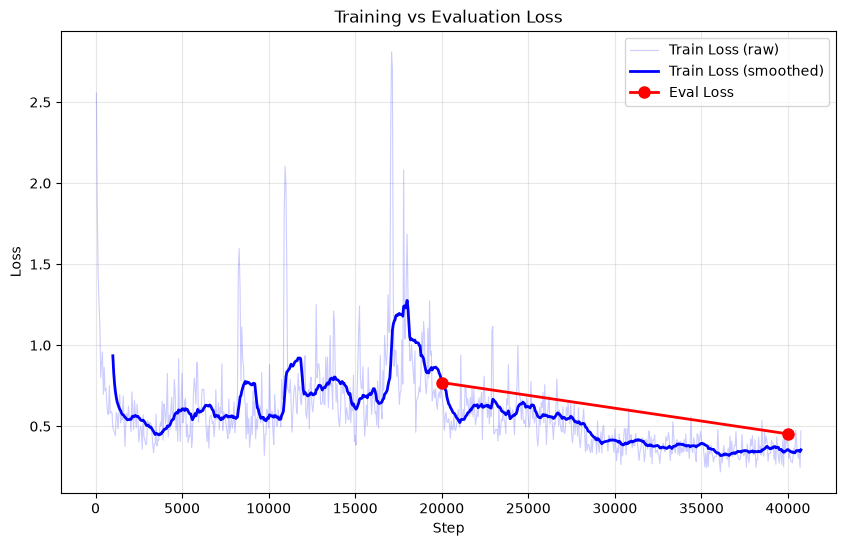

In [40]:
import pandas as pd

train_values_smooth = pd.Series(train_values).rolling(window=20).mean()

plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_values, label="Train Loss (raw)", alpha=0.2, linewidth=0.8, color="blue")
plt.plot(train_steps, train_values_smooth, label="Train Loss (smoothed)", linewidth=2, color="blue")
plt.plot(eval_steps, eval_values, label="Eval Loss", marker="o", markersize=8, linewidth=2, color="red")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training vs Evaluation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()